<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_1_Alzheimer's_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Prediction Project
This includes has EDA visualizations, feature importance, model evaluation and interpretations.

# 1. Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving alzheimers_prediction_dataset.csv to alzheimers_prediction_dataset.csv


# 2. Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('alzheimers_prediction_dataset.csv')
df.head()

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


# 3. Dataset Overview and Missing Values

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

# This will help us understand the number of rows, columns, and missing values.

(74283, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Fam

# 4. Data Cleaning

In [4]:
df = df.drop_duplicates()

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum())

0


# 5. Exploratory Data Analysis (EDA)

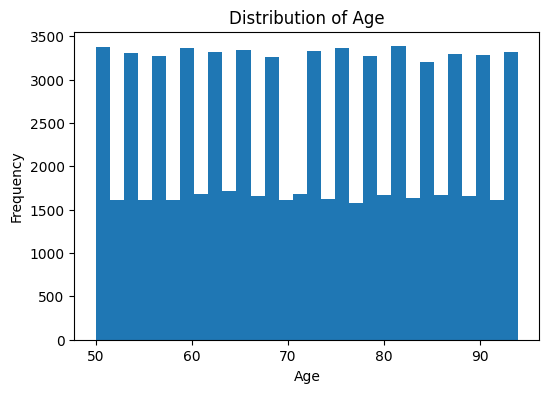

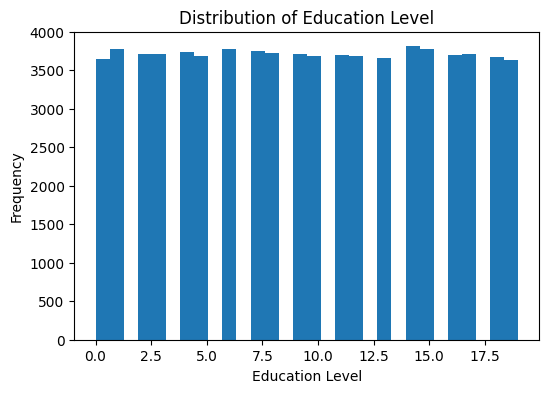

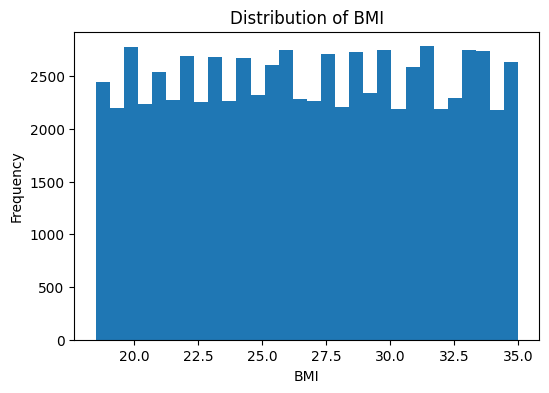

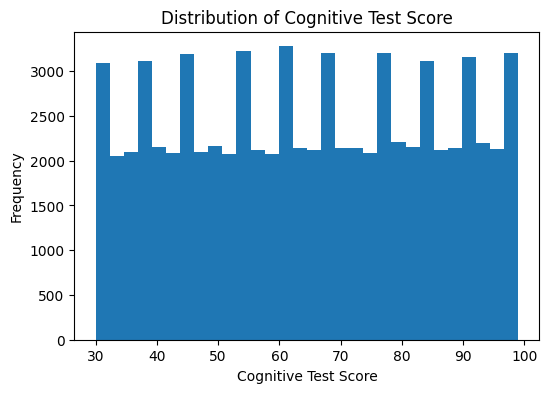

In [9]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns[:4]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# These graphs help pick the data spread skewness and outliers.

# 6. Correlation Analysis

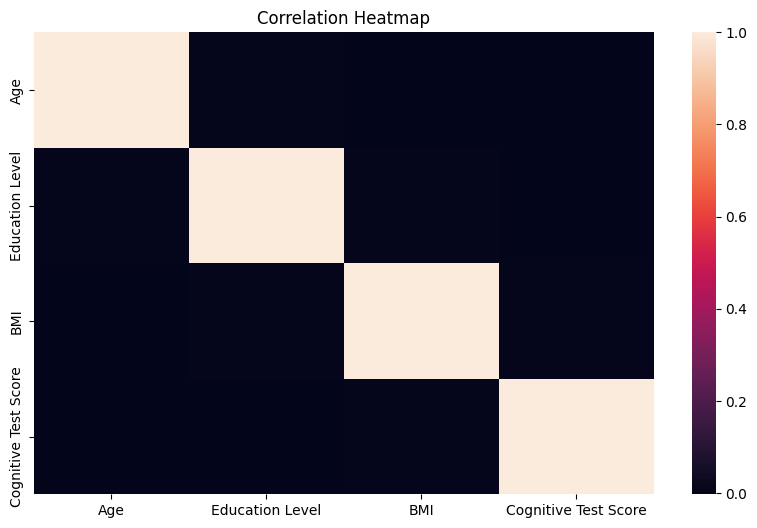

In [10]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=False)
plt.title('Correlation Heatmap')
plt.show()

# Highly correlated variables might show some redundancy.

# 7. Encoding and Scaling

In [8]:
# Identifying the target column BEFORE encoding
print(df.columns)

target_col = 'Alzheimer’s Diagnosis'  # adjust if needed based on print

# Encoding the dataset
df_encoded = pd.get_dummies(df, drop_first=True)

# Finding the correct encoded target column
target_cols = [col for col in df_encoded.columns if 'Alzheimer' in col]
print("Target columns after encoding:", target_cols)

# Usually binary -> take first match
target_col_encoded = target_cols[0]

# Splitting the features and target
X = df_encoded.drop(target_col_encoded, axis=1)
y = df_encoded[target_col_encoded]

# Scaling it
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='object')
Target columns after encoding: ['Family History of Alzheimer’s_Yes', 'Alzheimer’s Diagnosis_Yes']


# 8. Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 9. Model Training

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
nn = MLPClassifier(max_iter=500, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
nn.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

# 10. Model Evaluation

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {'Logistic Regression': lr, 'Random Forest': rf, 'Neural Network': nn}

for name, model in models.items():
    pred = model.predict(X_test)
    print(f'\n{name}')
    print('Accuracy:', accuracy_score(y_test, pred))
    print('Precision:', precision_score(y_test, pred, average='weighted'))
    print('Recall:', recall_score(y_test, pred, average='weighted'))
    print('F1 Score:', f1_score(y_test, pred, average='weighted'))
    print(confusion_matrix(y_test, pred))

# Comparing all models and chooseing the one with best F1 score.


Logistic Regression
Accuracy: 0.698660564043885
Precision: 0.7442653775614283
Recall: 0.698660564043885
F1 Score: 0.5760556016545478
[[10363     3]
 [ 4474    17]]

Random Forest
Accuracy: 0.6998048058154406
Precision: 0.6625082901601363
Recall: 0.6998048058154406
F1 Score: 0.5890865141597854
[[10274    92]
 [ 4368   123]]

Neural Network
Accuracy: 0.6464292925893518
Precision: 0.6027190348821694
Recall: 0.6464292925893518
F1 Score: 0.6153188499476797
[[8659 1707]
 [3546  945]]


# 11. Top 5 Important Features

BMI                          0.101024
Cognitive Test Score         0.095158
Age                          0.091652
Education Level              0.077460
Alzheimer’s Diagnosis_Yes    0.022889
dtype: float64


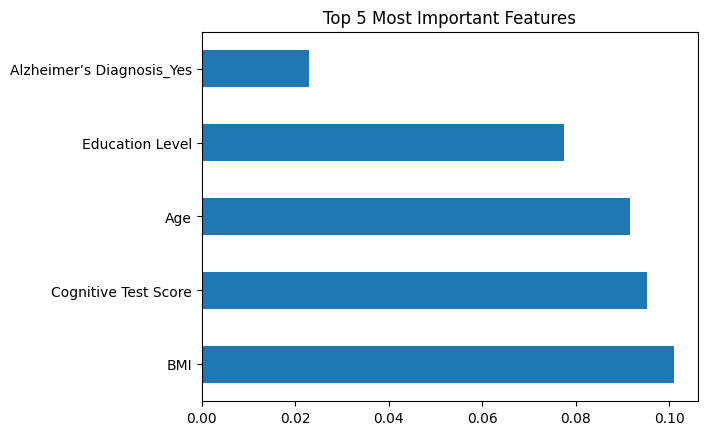

In [14]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top5 = importance.nlargest(5)

print(top5)

top5.plot(kind='barh')
plt.title('Top 5 Most Important Features')
plt.show()

# These are possibly the top 5 ranked reasons behind Alzheimer prediction.